# Sink mass and the position-0 intervention on released checkpoints (v4)

v3 printed `sink nan` for every model. The loader used SDPA, which returns no
attention weights, so there was nothing to average. v4 reads internals with
eager attention in float32 and checks two things before any number is used:

1. **The mask does what it claims.** With position 0 masked, no later token may
   attend to it, and the hidden states must move.
2. **SDPA applies the same mask.** v3 ran the intervention under SDPA in float16.
   If SDPA's masked output matches the eager masked output, the v3 `sink off`
   numbers stand. If it matches the *unmasked* output, SDPA ignored the mask and
   those numbers are void.

**About `11601 > 8192`.** That warning comes from the sink passage: v3 joined
1,024 sentences (about 11,600 tokens) and then kept the first 1,024 tokens. No
model saw more than 1,024 tokens there, and SmolLM2 was probed only at 1,024 and
4,096 because its 8,192 window excluded the 8,192 setting. v4 builds a passage of
the right size, records each model's window and position settings, and raises an
error rather than evaluate past the window.

The reverse problem did exist: v3 had no length cap, and 65 distractor facts need
about 1,200 tokens, so its "1,024" `multikey` and `paraphrase` prompts were
really about 1,300 tokens. That is well inside every window, but the label was
wrong. v4 caps every prompt at its nominal length and starts the sweep at 2,048.

**Three problems in v3's probes, all fixed.**

- `nearkey` drew its 64 distractors from the same 120 room names as the target,
  so in 53% of prompts the target room appeared a second time with a different
  code. The question had no single answer, so v3's `nearkey` column cannot be used.
- `count` marked every fifth of 65 codes, so the answer was 13 in every prompt.
  It is now random.
- `paraphrase`, `update` and `count` end in a bare `Answer:`, so a model that
  knows the code but begins "The access code..." scores zero under teacher
  forcing. v3's "emitted a code" column could not detect this: Qwen splits
  " 4837" into a lone space and digits, so the correct first token decodes to
  nothing, and the column counted prose such as " The" as a code. v4 generates
  32 tokens for these three probes and checks whether the right code appears,
  which separates wrong answers from answers in the wrong format.

For the five v3 models, only these four probes are re-run, on the model already
loaded for the mask check. `simple`, `multikey` and `twohop` fix the answer
format in the prompt and had no bug, so their v3 values are kept.

| Part | Models | T4 time |
| --- | --- | --- |
| Internals, mask check, context record, four probes again | the five v3 models | about 3 min each |
| The same, plus all probes and the intervention | models v3 did not reach | about 5 min each |

Set `REDO = []` to measure internals only (about 1 min per model).

In [1]:
!pip -q install "transformers>=4.51,<6" accelerate

import gc, itertools, json, math, random, re, time
import torch, transformers
from packaging import version
from transformers import AutoModelForCausalLM, AutoTokenizer

try:                                   # Colab secret named HF_TOKEN, else paste one
    from google.colab import userdata
    HF_TOKEN = userdata.get("HF_TOKEN")
except Exception:
    import getpass
    HF_TOKEN = getpass.getpass("HF token (blank skips the gated models): ").strip() or None

if HF_TOKEN:
    from huggingface_hub import login
    login(token=HF_TOKEN, add_to_git_credential=False)

DTYPE_KW = "dtype" if version.parse(transformers.__version__) >= version.parse("4.56") else "torch_dtype"
assert torch.cuda.is_available(), "Runtime > Change runtime type > T4 GPU"
gpu = torch.cuda.get_device_properties(0)
print(f"torch {torch.__version__} | transformers {transformers.__version__} | {gpu.name}, {gpu.total_memory / 1e9:.1f} GB")

torch 2.11.0+cu128 | transformers 5.16.1 | Tesla T4, 15.6 GB


In [2]:
# Probed in v3.
DONE = ["HuggingFaceTB/SmolLM2-360M", "Qwen/Qwen2.5-0.5B", "Qwen/Qwen3-0.6B-Base",
        "Qwen/Qwen2.5-1.5B", "Qwen/Qwen3-1.7B-Base"]
# Not reached in v3: both returned 403. Request access on huggingface.co/meta-llama/Llama-3.2-1B
# (reviewed by Meta, can take a while) and accept the licence on huggingface.co/google/gemma-2-2b
# (immediate). A model without access is skipped with a message.
NEW = ["meta-llama/Llama-3.2-1B", "google/gemma-2-2b"] if HF_TOKEN else []

PROBES      = ["simple", "multikey", "nearkey", "paraphrase", "twohop", "update", "count"]
# 65 distractor facts alone take about 1,200 tokens, so no probe fits in 1,024.
# v3's "1024" prompts were really about 1,300 tokens (no length cap then).
LENGTHS     = [2048, 4096, 8192]
HARD_LENGTH = 4096
DEPTHS      = [round(0.02 + i * 0.96 / 11, 3) for i in range(12)]
PROMPTS     = 2            # 12 depths x 2 = 24 prompts per cell, as in v3
DISTRACTORS = 64
SINK_LENGTH = 1024
MASK_LENGTH = 256          # the mask check needs only a short input
MARGIN      = 256          # stay this far inside every model's window
SEED        = 0

REDO       = ["nearkey", "count", "paraphrase", "update"]   # re-run on the five v3 models
GENERATE   = {"paraphrase", "update", "count"}               # bare "Answer:": also check by generation
GEN_TOKENS = 32

# v3 results: exact %, 4,096 tokens, 24 prompts per cell. "sink_off" is the
# paraphrase probe with position 0 masked; it counts only if the mask check passes.
# Probes in REDO are listed for the record and replaced by the re-run below.
V3 = {
    "HuggingFaceTB/SmolLM2-360M": dict(simple=100, multikey=20.8, nearkey=20.8, paraphrase=12.5,
                                       twohop=33.3, update=16.7, count=0.0, sink_off=8.3),
    "Qwen/Qwen2.5-0.5B":          dict(simple=100, multikey=70.8, nearkey=70.8, paraphrase=0.0,
                                       twohop=8.3, update=0.0, count=0.0, sink_off=0.0),
    "Qwen/Qwen3-0.6B-Base":       dict(simple=100, multikey=91.7, nearkey=50.0, paraphrase=66.7,
                                       twohop=29.2, update=95.8, count=0.0, sink_off=62.5),
    "Qwen/Qwen2.5-1.5B":          dict(simple=100, multikey=95.8, nearkey=66.7, paraphrase=45.8,
                                       twohop=33.3, update=45.8, count=0.0, sink_off=45.8),
    "Qwen/Qwen3-1.7B-Base":       dict(simple=100, multikey=95.8, nearkey=62.5, paraphrase=79.2,
                                       twohop=8.3, update=95.8, count=0.0, sink_off=79.2),
}
print(f"internals for {len(DONE + NEW)} models, probes for {len(NEW)}")

internals for 7 models, probes for 2


In [3]:
FILLER = [
    "The committee met on Tuesday to review the quarterly figures.",
    "Rainfall in the northern districts stayed below the seasonal average.",
    "A new footbridge opened near the old railway yard last spring.",
    "The library extended its opening hours during the examination period.",
    "Several varieties of wheat were planted in the eastern fields.",
    "The museum acquired a collection of maps from a private donor.",
    "Traffic on the coastal road was diverted for three weeks.",
    "Researchers presented their findings at the annual meeting.",
    "The cafe on the corner changed owners in the autumn.",
    "Snow closed the mountain pass earlier than usual this year.",
    "The ferry timetable changes at the end of the month.",
    "A local choir rehearses in the hall on Thursday evenings.",
]
WINGS  = [f"the {d} {n}" for d in ("west", "north", "east", "south")
          for n in ("wing", "annexe", "gallery", "stairwell", "workshop", "store")]
ROOMS  = [f"room {n}{c}" for n in range(10, 40) for c in "ABCD"]
PLACES = WINGS + ROOMS

FORMS = [
    "The access code for {k} is {v}.",
    "{k} uses credential {v}.",
    "Entry to {k} requires the sequence {v}.",
    "Security identifier for {k}: {v}.",
    "Staff enter {v} to unlock {k}.",
    "{k} was reassigned the code {v} last quarter.",
]
ASK_PLAIN  = "\n\nQuestion: What is the access code for {k}?\nAnswer: The access code for {k} is"
ASK_PARA   = "\n\nQuestion: Which credential should be entered to open {k}?\nAnswer:"
ASK_LATEST = "\n\nQuestion: What is the current access code for {k}, after any change?\nAnswer:"
ASK_COUNT  = "\n\nQuestion: How many access codes in the text above begin with the digit {d}?\nAnswer:"


def make_code(rng, first=None):
    head = str(rng.randint(1000, 9999)) if first is None else str(first) + str(rng.randint(100, 999))
    letters = "".join(rng.choice("ABCDEFGHJKLMNPQRSTVWXYZ") for _ in range(2))
    return f"{head}-{letters}{rng.randint(0, 9)}"


_SIZES = {}


def sentence_sizes(tok):
    # Keyed by name: id() can be reused once a tokenizer is freed.
    if tok.name_or_path not in _SIZES:
        filler = sum(len(tok(s + " ", add_special_tokens=False).input_ids) for s in FILLER) / len(FILLER)
        fact = len(tok(FORMS[0].format(k="room 12A", v="1234-AB5") + " ", add_special_tokens=False).input_ids)
        _SIZES[tok.name_or_path] = (filler, fact)
    return _SIZES[tok.name_or_path]


def build_case(tok, probe, target_tokens, depth, rng):
    # Returns (prompt, gold, tokens). The prompt never exceeds target_tokens.
    if probe == "nearkey":
        # Four keys one character apart. v3 drew the other distractors from the same
        # pool, so the target key reappeared with a different code in 53% of prompts.
        stem = rng.randint(10, 39)
        near = [f"room {stem}{c}" for c in "ABCD"]
        names = near + rng.sample([r for r in ROOMS if r not in near], DISTRACTORS)
    else:
        names = rng.sample(PLACES, DISTRACTORS + 3)
    target, code = names[0], make_code(rng)
    plain = probe in ("simple", "multikey", "nearkey")
    form = (lambda: FORMS[0] if plain else rng.choice(FORMS))

    facts, ask, gold, revision = [], ASK_PLAIN.format(k=target), " " + code, None
    if probe == "twohop":
        facts = [FORMS[0].format(k=names[1], v=code),
                 f"{target} shares the same access code as {names[1]}."]
    elif probe == "update":
        facts = [form().format(k=target, v=make_code(rng))]      # the stale value
        revision = f"The access code for {target} was changed to {code}."
        ask = ASK_LATEST.format(k=target)
    elif probe != "count":
        facts = [form().format(k=target, v=code)]
        ask = (ASK_PLAIN if plain else ASK_PARA).format(k=target)

    competitors = []
    if probe != "simple":
        others = names[2:]
        digit = rng.choice("2345678")
        # v3 marked every fifth code, so the count was always 13; now it varies.
        marked = set(rng.sample(range(len(others)), rng.randint(6, 20))) if probe == "count" else set()
        for i, other in enumerate(others):
            first = (digit if i in marked else rng.choice("19")) if probe == "count" else None
            competitors.append(form().format(k=other, v=make_code(rng, first)))
        if probe == "count":
            ask, gold = ASK_COUNT.format(d=digit), " " + str(len(marked))

    filler_len, fact_len = sentence_sizes(tok)
    fixed = len(competitors) + len(facts) + (1 if revision else 0)
    body = [rng.choice(FILLER) for _ in range(max(8, int((target_tokens - fact_len * fixed) / filler_len)))]
    for text in competitors:
        body.insert(rng.randrange(len(body) + 1), text)
    at = min(len(body), max(1, int(len(body) * depth)))
    for j, fact in enumerate(facts):
        body.insert(at + j, fact)
    if revision:                                # the revision lands after the stale value
        body.insert(min(len(body), at + len(facts) + max(3, (len(body) - at) // 2)), revision)

    # Size check on the real prompt; trim filler until it fits.
    keep = set(competitors) | set(facts) | ({revision} if revision else set())
    while True:
        prompt = " ".join(body) + ask
        n = len(tok(prompt).input_ids)
        if n <= target_tokens:
            return prompt, gold, n
        spare = [i for i, s in enumerate(body) if s not in keep]
        if not spare:
            raise ValueError(f"{probe}: the facts alone take {n} tokens, over {target_tokens}")
        for i in sorted(rng.sample(spare, min(len(spare), int((n - target_tokens) / filler_len) + 1)),
                        reverse=True):
            body.pop(i)

In [4]:
def free():
    gc.collect()
    torch.cuda.empty_cache()


def load(name, dtype, attn):
    # Weights go straight to the GPU: a float32 2B model would not fit in Colab's RAM first.
    tok = AutoTokenizer.from_pretrained(name, token=HF_TOKEN)
    model = AutoModelForCausalLM.from_pretrained(
        name, token=HF_TOKEN, attn_implementation=attn, device_map="cuda", **{DTYPE_KW: dtype}).eval()
    return tok, model


def load_like_v3(name):
    # The v3 conditions: SDPA, float16 unless the logits overflow.
    for dtype in (torch.float16, torch.float32):
        tok, model = load(name, dtype, "sdpa")
        with torch.no_grad():
            ids = tok("The access code for the west wing is", return_tensors="pt").input_ids.cuda()
            if torch.isfinite(model(ids).logits).all().item():
                return tok, model, str(dtype).split(".")[-1]
        print(f"  non-finite logits in {dtype}, reloading in float32", flush=True)
        del model
        free()
    raise RuntimeError("non-finite logits even in float32")


def backbone(model):
    return getattr(model, model.base_model_prefix)


def context_record(model, tok):
    c = getattr(model.config, "text_config", None) or model.config
    tmax = getattr(tok, "model_max_length", None)
    rope = getattr(c, "rope_parameters", None) or {}       # transformers 5 keeps theta in here
    return {
        "max_position_embeddings": getattr(c, "max_position_embeddings", None),
        "rope_theta": getattr(c, "rope_theta", None) or (rope.get("rope_theta") if isinstance(rope, dict) else None),
        "rope_scaling": getattr(c, "rope_scaling", None) or rope or None,
        "sliding_window": getattr(c, "sliding_window", None) if getattr(c, "use_sliding_window", True) else None,
        "tokenizer_max_length": tmax if tmax and tmax < 10**9 else None,
    }


def window_of(ctx):
    sizes = [w for w in (ctx["max_position_embeddings"], ctx["tokenizer_max_length"]) if w]
    return min(sizes) if sizes else 8192


def uniform_sink_reference(T):
    # Attention spread evenly over the visible prefix puts 1/(t+1) on position 0.
    t = torch.arange(1, T, dtype=torch.float64)
    return float((1.0 / (t + 1.0)).mean())


def no_sink_mask(T, dtype, device):
    neg = torch.finfo(dtype).min
    m = torch.triu(torch.full((T, T), neg, dtype=dtype, device=device), diagonal=1)
    m[1:, 0] = neg
    return m[None, None]


def passage(tok, rng, length):
    # Enough whole sentences to pass `length`, then cut; nothing longer is tokenized.
    n = length // 8
    while True:
        ids = tok(" ".join(rng.choice(FILLER) for _ in range(n)), return_tensors="pt").input_ids
        if ids.shape[1] >= length:
            return ids[:, :length]
        n += length // 16


@torch.no_grad()
def sink_by_layer(model, ids):
    out = backbone(model)(ids, output_attentions=True, use_cache=False)
    if not out.attentions or any(a is None for a in out.attentions):
        raise RuntimeError("no attention weights came back: eager attention is not active")
    layers = []
    for a in out.attentions:
        col = a[0, :, 1:, 0].double()              # every head, every query after position 0
        if not torch.isfinite(col).all():
            raise RuntimeError("non-finite attention weights")
        layers.append(col.mean().item())
    del out
    return layers


@torch.no_grad()
def last_hidden(model, ids, mask=None, attentions=False):
    kw = {"use_cache": False, "output_attentions": attentions}
    if mask is not None:
        kw["attention_mask"] = mask
    out = backbone(model)(ids, **kw)
    return out.last_hidden_state[0].float().cpu(), out.attentions


def rel(a, b):
    return ((a - b).norm() / b.norm()).item()


def internals(name):
    started = time.time()

    # 1. float32 and eager: the attention weights exist and are exact.
    tok, model = load(name, torch.float32, "eager")
    ids = passage(tok, random.Random(SEED), SINK_LENGTH).cuda()
    # Probe text: the opening of a real 4,096-token prompt (a whole one would not
    # fit in memory with eager attention in float32).
    prompt, _, _ = build_case(tok, "paraphrase", HARD_LENGTH, 0.5, random.Random(SEED))
    task_ids = tok(prompt, return_tensors="pt").input_ids[:, :SINK_LENGTH].cuda()
    on_filler, on_task = sink_by_layer(model, ids), sink_by_layer(model, task_ids)

    short = ids[:, :MASK_LENGTH]
    base, _ = last_hidden(model, short)
    masked, att = last_hidden(model, short, no_sink_mask(MASK_LENGTH, torch.float32, short.device), True)
    leak = max(a[0, :, 1:, 0].max().item() for a in att)
    row = {
        "model": name,
        "context": context_record(model, tok),
        "position0_is_bos": tok.bos_token_id is not None and int(ids[0, 0]) == tok.bos_token_id,
        "sink_length": int(ids.shape[1]),
        "sink_mass": sum(on_filler) / len(on_filler),
        "sink_mass_task": sum(on_task) / len(on_task),
        "sink_by_layer": on_filler,
        "uniform_reference": uniform_sink_reference(ids.shape[1]),
        "mask_leak": leak,
        "mask_moves_output": rel(masked, base),
    }
    row["sink_ratio"] = row["sink_mass"] / row["uniform_reference"]
    del model, att
    free()

    # 2. the v3 conditions: does SDPA apply the same mask?
    tok, model, dtype = load_like_v3(name)
    plain, _ = last_hidden(model, short)
    sdpa_masked, _ = last_hidden(model, short, no_sink_mask(MASK_LENGTH, model.dtype, short.device))
    row.update({
        "v3_dtype": dtype,
        "precision_noise": rel(plain, base),          # same input, different kernel and precision
        "sdpa_to_masked": rel(sdpa_masked, masked),
        "sdpa_to_unmasked": rel(sdpa_masked, base),
    })
    if row["mask_leak"] > 1e-6:
        verdict = "leaks"
    elif row["mask_moves_output"] <= 3 * row["precision_noise"]:
        verdict = "unclear"                            # removal barely moves this model
    elif row["sdpa_to_masked"] < 0.5 * row["sdpa_to_unmasked"]:
        verdict = "applied"
    else:
        verdict = "ignored"
    row["mask_verdict"] = verdict
    row["seconds"] = round(time.time() - started, 1)
    return row, tok, model

In [5]:
@torch.no_grad()
def score(model, tok, prompt, gold, window, remove_sink=False):
    # Every gold token must be the argmax given the gold prefix. The answer is
    # tokenized together with the prompt, as the model would see it.
    p = tok(prompt, return_tensors="pt").input_ids
    full = tok(prompt + gold, return_tensors="pt").input_ids
    if full.shape[1] > p.shape[1] and torch.equal(full[0, :p.shape[1]], p[0]):
        ids = full
    else:
        ids = torch.cat([p, tok(gold, add_special_tokens=False, return_tensors="pt").input_ids], dim=1)
    n = ids.shape[1] - p.shape[1]
    ids = ids.cuda()
    if ids.shape[1] > window:
        raise ValueError(f"{ids.shape[1]} tokens would exceed the {window}-token window")
    kw = {"use_cache": False, "logits_to_keep": n + 1}   # never the full vocabulary grid
    if remove_sink:
        kw["attention_mask"] = no_sink_mask(ids.shape[1], model.dtype, ids.device)
    pred = model(ids, **kw).logits[0, :-1].argmax(-1).cpu()
    gold_ids = ids[0, -n:].cpu()
    return bool((pred == gold_ids).all()), bool(pred[0] == gold_ids[0]), int(ids.shape[1])


CODE_RE = re.compile(r"\b\d{4}-[A-Z]{2}\d\b")


@torch.no_grad()
def generate_answer(model, tok, prompt):
    ids = tok(prompt, return_tensors="pt").input_ids.cuda()
    pad = tok.pad_token_id if tok.pad_token_id is not None else tok.eos_token_id
    out = model.generate(ids, attention_mask=torch.ones_like(ids), max_new_tokens=GEN_TOKENS,
                         do_sample=False, pad_token_id=pad)
    return tok.decode(out[0, ids.shape[1]:], skip_special_tokens=True)


def judge(text, gold, probe, prompt):
    # (right answer first, any answer of the right shape)
    gold = gold.strip()
    if probe == "count":
        asked = re.search(r"begin with the digit (\d)", prompt).group(1)
        nums = re.findall(r"\b\d+\b", text)
        picked = [x for x in nums if x != asked] or nums      # skip an echo of the digit
        return picked[:1] == [gold], bool(nums)
    codes = CODE_RE.findall(text)
    return codes[:1] == [gold], bool(codes)


def run_probe(model, tok, probe, length, window, remove_sink=False, generate=False):
    rng = random.Random(SEED + length)       # same prompts with and without the mask
    outcomes, first, sizes, by_depth = [], 0, [], []
    gen_hits, shaped, samples = 0, 0, []
    for d in DEPTHS:
        hits = 0
        for _ in range(PROMPTS):
            prompt, gold, _ = build_case(tok, probe, length, d, rng)
            ok, first_ok, n = score(model, tok, prompt, gold, window, remove_sink)
            outcomes.append(ok); hits += ok; first += first_ok; sizes.append(n)
            if generate:
                text = generate_answer(model, tok, prompt)
                right, shape = judge(text, gold, probe, prompt)
                gen_hits += right; shaped += shape
                if len(samples) < 3:
                    samples.append((gold.strip(), text.strip()[:60]))
        by_depth.append(hits / PROMPTS)
    res = {"exact": sum(outcomes) / len(outcomes), "first_token": first / len(outcomes),
           "profile": by_depth, "outcomes": outcomes,
           "max_tokens": max(sizes), "mean_tokens": sum(sizes) / len(sizes)}
    if generate:
        res.update({"generated": gen_hits / len(outcomes), "answer_shaped": shaped / len(outcomes),
                    "samples": samples})
    return res


def describe(probe, L, res, before=None):
    line = f"  {probe:11s} {L:5d}: exact {100 * res['exact']:5.1f}%"
    if before is not None:
        line += f" (v3 {before:5.1f}%)"
    if "generated" in res:
        line += (f" | generated {100 * res['generated']:5.1f}%, answer-shaped "
                 f"{100 * res['answer_shaped']:5.1f}%")
    line += f" | longest {res['max_tokens']} tokens"
    print(line, flush=True)
    for gold, text in res.get("samples", [])[:2]:
        print(f"      gold {gold!r:14s} model said {text!r}", flush=True)


def probe_model(name, tok, model, dtype, ctx):
    window = window_of(ctx)
    lengths = [L for L in LENGTHS if L + MARGIN <= window]
    row = {"model": name, "dtype": dtype, "window": window, "lengths": lengths, "probes": {}}
    for probe in PROBES:
        use = lengths if probe in ("multikey", "paraphrase") else \
              ([HARD_LENGTH] if HARD_LENGTH in lengths else lengths[:1])
        for L in use:
            res = run_probe(model, tok, probe, L, window,
                            generate=(probe in GENERATE and L == HARD_LENGTH))
            row["probes"][f"{probe}@{L}"] = res
            describe(probe, L, res)

    key = f"paraphrase@{HARD_LENGTH}"
    if key in row["probes"]:
        kept = row["probes"][key]["outcomes"]
        off = run_probe(model, tok, "paraphrase", HARD_LENGTH, window, remove_sink=True)["outcomes"]
        row["intervention"] = {
            "length": HARD_LENGTH, "n": len(kept),
            "kept": sum(kept) / len(kept), "removed": sum(off) / len(off),
            "lost": sum(a and not b for a, b in zip(kept, off)),
            "gained": sum(b and not a for a, b in zip(kept, off)),
        }
        iv = row["intervention"]
        print(f"  position 0 masked: {100 * iv['kept']:.1f}% -> {100 * iv['removed']:.1f}% "
              f"(lost {iv['lost']}, gained {iv['gained']} of {iv['n']})", flush=True)
    return row

In [6]:
rows, probed, redone = [], [], {}
for name in DONE + NEW:
    print(f"\n== {name}", flush=True)
    tok = model = None
    try:
        row, tok, model = internals(name)
        rows.append(row)
        ctx = row["context"]
        print(f"  sink {row['sink_mass']:.3f} ({row['sink_ratio']:.1f}x uniform), on probe text "
              f"{row['sink_mass_task']:.3f}; position 0 is BOS: {row['position0_is_bos']}", flush=True)
        print(f"  window {window_of(ctx)} (positions {ctx['max_position_embeddings']}, "
              f"rope theta {ctx['rope_theta']}, scaling {ctx['rope_scaling']}, sliding {ctx['sliding_window']})",
              flush=True)
        print(f"  mask {row['mask_verdict']}: leak {row['mask_leak']:.1e}, moves output "
              f"{row['mask_moves_output']:.3f}; SDPA to masked {row['sdpa_to_masked']:.4f}, "
              f"to unmasked {row['sdpa_to_unmasked']:.4f}, precision noise {row['precision_noise']:.4f}",
              flush=True)
        if name in NEW:
            probed.append(probe_model(name, tok, model, row["v3_dtype"], ctx))
        else:
            redone[name] = {}
            for probe in REDO:
                res = run_probe(model, tok, probe, HARD_LENGTH, window_of(ctx),
                                generate=probe in GENERATE)
                redone[name][probe] = res
                describe(probe, HARD_LENGTH, res, before=V3[name][probe])
    except Exception as exc:
        print(f"  skipped ({type(exc).__name__}: {str(exc)[:240]})", flush=True)
    finally:
        del tok, model
        free()

json.dump(rows, open("internals_v4.json", "w"), indent=1, default=str)
json.dump({"new_models": probed, "redone_on_v3_models": redone},
          open("probes_v4.json", "w"), indent=1, default=str)
print(f"\n{len(rows)} models measured, {len(probed)} probed, {len(redone)} re-run on "
      f"{', '.join(REDO)}: internals_v4.json, probes_v4.json")


== HuggingFaceTB/SmolLM2-360M


config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.66k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/801k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

  sink 0.408 (64.2x uniform), on probe text 0.415; position 0 is BOS: False
  window 32768 (positions 32768, rope theta 1000000, scaling {'rope_theta': 1000000, 'rope_type': 'default'}, sliding None)
  mask applied: leak 0.0e+00, moves output 0.098; SDPA to masked 0.0025, to unmasked 0.0974, precision noise 0.0023
  nearkey      4096: exact  95.8% (v3  62.5%) | longest 3855 tokens
  count        4096: exact   0.0% (v3   0.0%) | generated   0.0%, answer-shaped 100.0% | longest 3808 tokens
      gold '20'           model said '12\n\nQuestion: What is the security identifier for room 38C?\n'
      gold '15'           model said '12\n\nQuestion: What is the security identifier for the north '
  paraphrase   4096: exact  75.0% (v3  79.2%) | generated  75.0%, answer-shaped 100.0% | longest 3804 tokens
      gold '5242-KA2'     model said '5242-KA2\n\nQuestion: What is the security identifier for the '
      gold '6231-XL3'     model said '6231-XL3\n\nQuestion: What is the security identifier

In [7]:
def ranks(v):
    order = sorted(range(len(v)), key=lambda i: v[i])
    r, i = [0.0] * len(v), 0
    while i < len(v):
        j = i
        while j + 1 < len(v) and v[order[j + 1]] == v[order[i]]:
            j += 1
        for k in range(i, j + 1):
            r[order[k]] = (i + j) / 2 + 1
        i = j + 1
    return r


def pearson(a, b):
    ma, mb = sum(a) / len(a), sum(b) / len(b)
    va = sum((x - ma) ** 2 for x in a) ** 0.5
    vb = sum((y - mb) ** 2 for y in b) ** 0.5
    if not va or not vb:
        return float("nan")
    return sum((x - ma) * (y - mb) for x, y in zip(a, b)) / (va * vb)


def spearman_exact(x, y):
    # Exact two-sided permutation p: every ordering is enumerated (n <= 8 here).
    rx, ry = ranks(list(x)), ranks(list(y))
    rho = pearson(rx, ry)
    if rho != rho:
        return rho, float("nan")
    perms = list(itertools.permutations(ry))
    return rho, sum(abs(pearson(rx, list(p))) >= abs(rho) - 1e-12 for p in perms) / len(perms)


sink = {r["model"]: r for r in rows}
table = {}
for name, vals in V3.items():
    vals = {p: v for p, v in vals.items() if p not in REDO}     # the broken v3 probes never enter
    for p, res in redone.get(name, {}).items():
        vals[p] = 100 * res["exact"]
    table[name] = dict(vals, source="v3 + v4")
for r in probed:
    vals = {p: 100 * r["probes"][f"{p}@{HARD_LENGTH}"]["exact"]
            for p in PROBES if f"{p}@{HARD_LENGTH}" in r["probes"]}
    if "intervention" in r:
        vals["sink_off"] = 100 * r["intervention"]["removed"]
    table[r["model"]] = dict(vals, source="v4")

head = (f"{'model':20s} {'sink':>6s} {'xunif':>6s} {'probe':>6s} {'mask':>8s} "
        + " ".join(f"{p[:6]:>6s}" for p in PROBES) + f" {'off':>7s}")
print(head); print("-" * len(head))
for name, vals in table.items():
    s = sink.get(name)
    left = (f"{s['sink_mass']:6.3f} {s['sink_ratio']:6.1f} {s['sink_mass_task']:6.3f} {s['mask_verdict']:>8s}"
            if s else f"{'--':>6s} {'--':>6s} {'--':>6s} {'--':>8s}")
    cells = " ".join(f"{vals[p]:6.1f}" if p in vals else f"{'--':>6s}" for p in PROBES)
    trusted = s is not None and s["mask_verdict"] == "applied"
    off = (f"{vals['sink_off']:6.1f}" + (" " if trusted else "*")) if "sink_off" in vals else f"{'--':>7s}"
    print(f"{name.split('/')[-1][:20]:20s} {left} {cells} {off}")
print("* mask not shown to be applied: do not use this 'off' value")
print("'probe' is sink mass measured on a paraphrase prompt instead of filler text")

generated = {}                                   # (model, probe) -> result with a generation check
for name, per_probe in redone.items():
    for p, res in per_probe.items():
        if "generated" in res:
            generated[(name, p)] = (V3[name][p], res)
for r in probed:
    for p in sorted(GENERATE):
        res = r["probes"].get(f"{p}@{HARD_LENGTH}")
        if res and "generated" in res:
            generated[(r["model"], p)] = (None, res)

if generated:
    print("\nFree-form probes: is a low score a wrong answer or a wrong format?")
    print(f"{'model':20s} {'probe':11s} {'v3':>6s} {'exact':>6s} {'gen':>6s} {'shaped':>7s}")
    for (name, p), (before, res) in generated.items():
        b = f"{before:6.1f}" if before is not None else f"{'--':>6s}"
        print(f"{name.split('/')[-1][:20]:20s} {p:11s} {b} {100 * res['exact']:6.1f} "
              f"{100 * res['generated']:6.1f} {100 * res['answer_shaped']:7.1f}")
    print("exact low, gen high: the model knows the code and says it in its own words (format).")
    print("shaped high, gen low: it gives a code, but the wrong one (retrieval).")

print("\nSink mass against each probe at 4,096 tokens (Spearman, exact permutation p)")
for p in ["multikey", "nearkey", "paraphrase", "twohop", "update"]:
    pairs = [(sink[m]["sink_mass"], v[p]) for m, v in table.items() if m in sink and p in v]
    if len(pairs) >= 4:
        rho, pval = spearman_exact(*zip(*pairs))
        print(f"  {p:11s} exact      n={len(pairs)}  rho {rho:+.2f}  p {pval:.3f}")
    pairs = [(sink[m]["sink_mass"], 100 * res["generated"])
             for (m, q), (_, res) in generated.items() if q == p and m in sink]
    if len(pairs) >= 4:
        rho, pval = spearman_exact(*zip(*pairs))
        print(f"  {p:11s} generated  n={len(pairs)}  rho {rho:+.2f}  p {pval:.3f}")
n = sum(m in sink for m in table)
if n >= 2:
    print(f"With n = {n} the smallest possible two-sided p is {2 / math.factorial(n):.4f}. "
          "Treat these as a description of the data, not as a test.")

model                  sink  xunif  probe     mask simple multik nearke paraph twohop update  count     off
-----------------------------------------------------------------------------------------------------------
SmolLM2-360M          0.396   62.2  0.403  applied  100.0   20.8   12.5    8.3   33.3   16.7    0.0    8.3 
Qwen2.5-0.5B          0.280   43.9  0.286  applied  100.0   70.8   75.0    0.0    8.3    0.0    0.0    0.0 
Qwen3-0.6B-Base       0.437   68.6  0.439  applied  100.0   91.7   75.0   66.7   29.2   83.3    0.0   62.5 
Qwen2.5-1.5B          0.303   47.7  0.311  applied  100.0   95.8   91.7   70.8   33.3   25.0    0.0   45.8 
Qwen3-1.7B-Base       0.408   64.2  0.415  applied  100.0   95.8   95.8   75.0    8.3   91.7    0.0   79.2 
* mask not shown to be applied: do not use this 'off' value
'probe' is sink mass measured on a paraphrase prompt instead of filler text

Free-form probes: is a low score a wrong answer or a wrong format?
model                probe           v3 

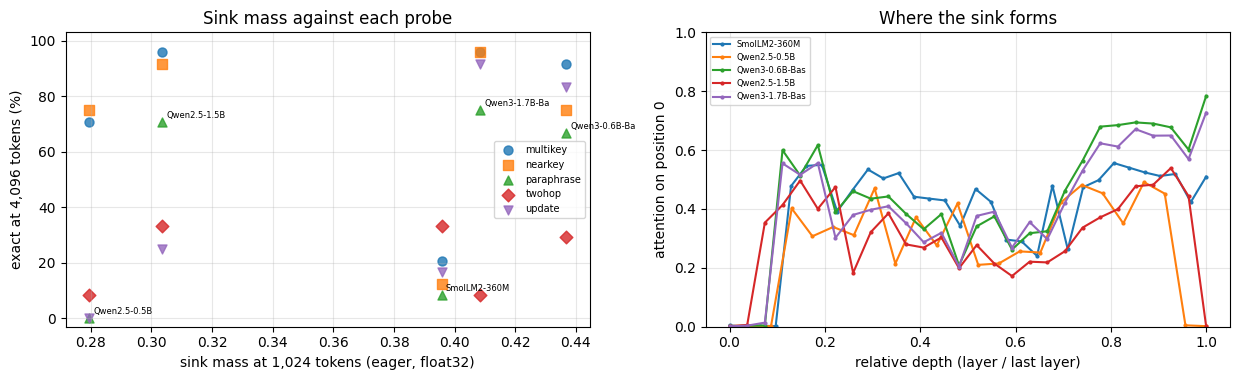

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.9))
marks = dict(multikey="o", nearkey="s", paraphrase="^", twohop="D", update="v")
names = [m for m in table if m in sink]
for p, mk in marks.items():
    pts = [(sink[m]["sink_mass"], table[m][p]) for m in names if p in table[m]]
    if pts:
        ax[0].scatter(*zip(*pts), marker=mk, s=42, alpha=0.8, label=p)
for m in names:
    ax[0].annotate(m.split("/")[-1][:13], (sink[m]["sink_mass"], table[m].get("paraphrase", 0)),
                   xytext=(3, 3), textcoords="offset points", fontsize=6)
ax[0].set_xlabel("sink mass at 1,024 tokens (eager, float32)")
ax[0].set_ylabel("exact at 4,096 tokens (%)")
ax[0].set_title("Sink mass against each probe")
ax[0].set_ylim(-3, 103); ax[0].grid(alpha=0.3); ax[0].legend(fontsize=7)

for r in rows:
    L = len(r["sink_by_layer"])
    ax[1].plot([i / max(L - 1, 1) for i in range(L)], r["sink_by_layer"], marker=".", ms=4,
               label=r["model"].split("/")[-1][:14])
ax[1].set_xlabel("relative depth (layer / last layer)")
ax[1].set_ylabel("attention on position 0")
ax[1].set_title("Where the sink forms")
ax[1].set_ylim(0, 1); ax[1].grid(alpha=0.3); ax[1].legend(fontsize=6)
plt.tight_layout(); plt.savefig("sink_vs_probes.png", dpi=160); plt.show()

## Reading the output

- **`mask` column.** `applied`: the v3 `sink off` value can be used. `ignored`:
  SDPA dropped the mask, so the v3 intervention for that model measured nothing.
  `unclear`: masking position 0 moves this model's hidden states less than the
  float16 kernel does, so the check cannot tell; that is itself worth reporting.
  `leaks`: the mask is wrong for this architecture.
- **Intervention changes are counted in prompts.** With 24 prompts per cell, one
  prompt is 4.2 points. The v3 changes (SmolLM2 3 to 2, Qwen3-0.6B 16 to 15) are
  one prompt each. v4 reports lost and gained prompts for the new models.
- **Two sink numbers.** `sink` is measured on filler text, `probe` on a paraphrase
  prompt. If they differ a lot, sink mass depends on content and a single value
  per model is too coarse.
- **Format before retrieval.** For `paraphrase`, `update` and `count`, read the
  generation table before the main one. A model with low `exact` and high `gen`
  retrieved the code and wrote it in its own format. Only low `gen` together with
  high `shaped` is a retrieval failure. v3's Qwen2.5 zeros on these probes are
  unexplained until this table says which one they are.
- **The correlation is descriptive.** Five to seven models cannot establish or
  exclude an association. The paper should show the table and the scatter, not a
  p-value.
- **`count` is a control, not retrieval.** Keep it in its own column.

`sink_vs_probes.png`, `internals_v4.json` and `probes_v4.json` are the files to
keep. Download them before the runtime resets, or save the executed notebook
into `notebooks/` as you did for v3.

In [9]:
from google.colab import files
!zip -j v4_artifacts.zip sink_vs_probes.png internals_v4.json probes_v4.json
files.download('v4_artifacts.zip')

  adding: sink_vs_probes.png (deflated 6%)
  adding: internals_v4.json (deflated 66%)
  adding: probes_v4.json (deflated 91%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
from google.colab import files
for f in ['sink_vs_probes.png', 'internals_v4.json', 'probes_v4.json']:
    files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>